# Nexus Notebook — Entanglement Cut, Gravity Operator, and the Triadic 9-Loop

**Purpose**

This notebook keeps the current branch in one place and reduces file sprawl.

The working discovery track is:

$$
\Gamma_S \to \rho_\Gamma \to \rho_{\mathrm{eff}} \to \Phi \to \text{observable}
$$

with the gravity branch currently treated as:

$$
\Gamma_S = \text{entanglement cut}
$$

$$
\rho_\Gamma = \beta\, s_{\mathrm{ent}} \quad \text{or} \quad \beta\, I_{\mathrm{mut}}
$$

$$
\rho_{\mathrm{eff}} = \rho_m + \varepsilon(H)\rho_\Gamma
$$

$$
\nabla^2 \Phi = 4\pi G\,\rho_{\mathrm{eff}}
$$

The parallel hypothesis being tracked here is the **triadic 9-loop**:

$$
3 \text{ verbs} \times 3 \text{ layers} = 9
$$

with:

- **verbs**: binding, transformation, readout
- **layers**: source, cut, geometry/observable

This notebook is meant to do two things:

1. keep the current map coherent,
2. push the branch toward one external observable.


In [9]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

H = math.pi / 9.0
EPS_H = H**2 / 24.0

print(f"H = pi/9 = {H:.12f}")
print(f"epsilon(H) = H^2/24 = {EPS_H:.12f}")

H = pi/9 = 0.349065850399
epsilon(H) = H^2/24 = 0.005076956996


## 1. The triadic 9-loop candidate

The current compact guess is:

| Layer | Binding | Transformation | Readout |
|---|---|---|---|
| Source | retained mass-energy / coherence basin | flow / evolution | ordinary stress-energy witness |
| Cut | nonseparability retention | modular flow / cut evolution | entanglement density $\rho_\Gamma$ |
| Geometry / Observable | trapped mass / stable geometry | geodesic propagation | lensing, precession, horizon entropy |

This is still a map, not a theorem. But it is a clean way to see where the branch is trying to go.


In [10]:
loop = pd.DataFrame(
    [
        ["retained mass-energy", "flow / evolution", "stress-energy witness"],
        ["nonseparability retention", "modular flow / cut evolution", "entanglement density rho_Gamma"],
        ["trapped mass / stable geometry", "geodesic propagation", "lensing / precession / horizon entropy"],
    ],
    index=["Source", "Cut", "Geometry/Observable"],
    columns=["Binding", "Transformation", "Readout"],
)
loop

,Binding,Transformation,Readout
Source,retained mass-energy,flow / evolution,stress-energy witness
Cut,nonseparability retention,modular flow / cut evolution,entanglement density rho_Gamma
Geometry/Observable,trapped mass / stable geometry,geodesic propagation,lensing / precession / horizon entropy


## 2. Discrete cut sanity check

A useful microscopic test is whether a cut variable behaves like a **surface** rather than a **volume** quantity.

We approximate that by counting nearest-neighbor cut edges for a lattice sphere in $\mathbb{Z}^3$.

If the branch is coherent, cut count should scale roughly like:

$$
N_{\mathrm{cut}}(R) \propto R^2
$$

while enclosed sites scale like:

$$
N_{\mathrm{vol}}(R) \propto R^3.
$$


cut-edge slope ~ 1.975
volume slope   ~ 2.989


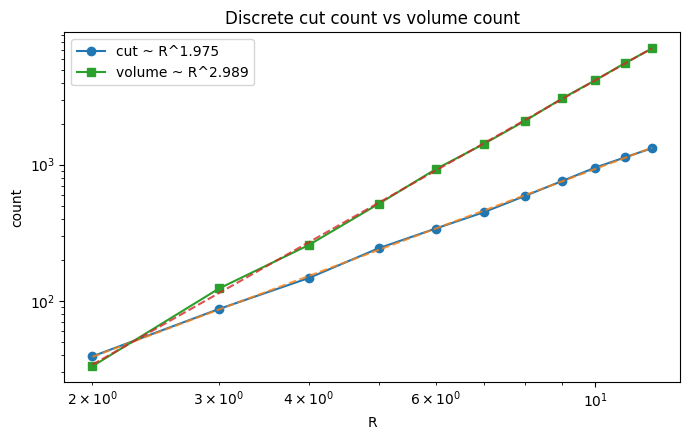

In [11]:
def count_cut_edges_sphere(R: int):
    pts = []
    for x in range(-R-1, R+2):
        for y in range(-R-1, R+2):
            for z in range(-R-1, R+2):
                if x*x + y*y + z*z <= R*R:
                    pts.append((x, y, z))
    region = set(pts)
    dirs = [(1,0,0), (0,1,0), (0,0,1)]  # count each undirected edge once
    cut = 0
    for x, y, z in region:
        for dx, dy, dz in dirs:
            nb = (x+dx, y+dy, z+dz)
            if nb not in region:
                cut += 1
    vol = len(region)
    return cut, vol

Rs = np.arange(2, 13)
cut_counts = []
vol_counts = []
for R in Rs:
    cut, vol = count_cut_edges_sphere(int(R))
    cut_counts.append(cut)
    vol_counts.append(vol)

logR = np.log(Rs.astype(float))
slope_cut, intercept_cut = np.polyfit(logR, np.log(np.array(cut_counts, dtype=float)), 1)
slope_vol, intercept_vol = np.polyfit(logR, np.log(np.array(vol_counts, dtype=float)), 1)

print(f"cut-edge slope ~ {slope_cut:.3f}")
print(f"volume slope   ~ {slope_vol:.3f}")

plt.figure(figsize=(7,4.5))
plt.loglog(Rs, cut_counts, "o-", label=f"cut ~ R^{slope_cut:.3f}")
plt.loglog(Rs, np.exp(intercept_cut) * Rs**slope_cut, "--", alpha=0.8)
plt.loglog(Rs, vol_counts, "s-", label=f"volume ~ R^{slope_vol:.3f}")
plt.loglog(Rs, np.exp(intercept_vol) * Rs**slope_vol, "--", alpha=0.8)
plt.xlabel("R")
plt.ylabel("count")
plt.title("Discrete cut count vs volume count")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Helix drag picture

The current geometric proof-of-principle is:

$$
\mathbf{r}(s)=
\begin{pmatrix}
r\cos(\omega s) \\
r\sin(\omega s) \\
vs
\end{pmatrix}
$$

with curvature

$$
\kappa = \frac{r\omega^2}{r^2\omega^2 + v^2}.
$$

Introduce cut-density drag:

$$
v_{\mathrm{eff}}(\rho_\Gamma)=\frac{v_0}{1+\lambda\rho_\Gamma}.
$$

Then higher cut density lowers the axial speed and raises the curvature.


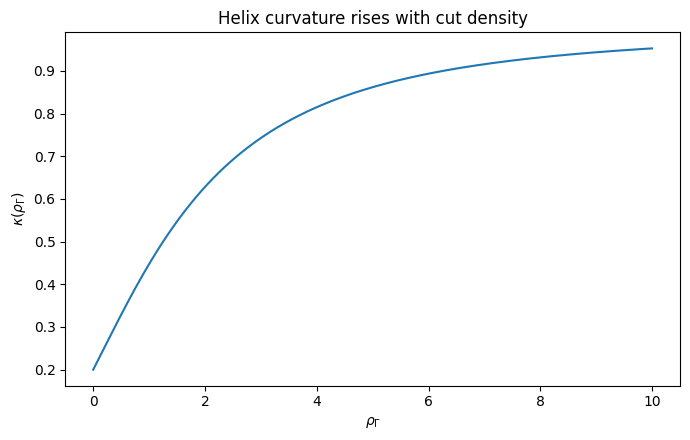

In [12]:
r_bind = 1.0
omega = 1.0
v0 = 2.0
lam = 0.8
rho_vals = np.linspace(0, 10, 300)

v_eff = v0 / (1 + lam * rho_vals)
kappa = r_bind * omega**2 / (r_bind**2 * omega**2 + v_eff**2)

plt.figure(figsize=(7,4.5))
plt.plot(rho_vals, kappa)
plt.xlabel(r"$\rho_\Gamma$")
plt.ylabel(r"$\kappa(\rho_\Gamma)$")
plt.title("Helix curvature rises with cut density")
plt.tight_layout()
plt.show()

## 4. Effective source law

The clean closure currently being used is linear in cut density:

$$
\rho_{\mathrm{eff}} = \rho_m + \alpha \rho_\Gamma
$$

with

$$
\alpha = \varepsilon(H).
$$

A practical proxy used in the toy model is:

$$
\rho_\Gamma(r) = \gamma \left(\frac{\rho_m(r)}{\rho_c}\right)^2.
$$

That gives a compact-source enhancement without the old unphysical $+r^2$ growth in the exterior potential.


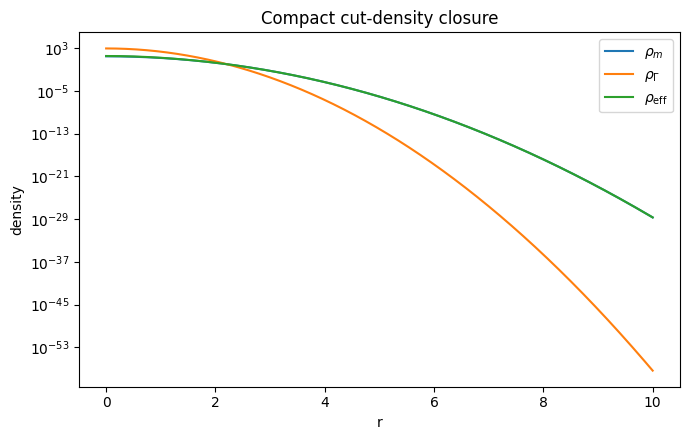

In [13]:
G = 1.0
rho_c = 1.0
alpha = EPS_H
gamma = 1.0

r = np.linspace(1e-3, 10.0, 4000)
rho0 = 30.0
R0 = 1.2

rho_m = rho0 * np.exp(-(r / R0) ** 2)
rho_gamma = gamma * (rho_m / rho_c) ** 2
rho_eff = rho_m + alpha * rho_gamma

plt.figure(figsize=(7,4.5))
plt.semilogy(r, rho_m, label=r"$\rho_m$")
plt.semilogy(r, rho_gamma, label=r"$\rho_\Gamma$")
plt.semilogy(r, rho_eff, label=r"$\rho_{\mathrm{eff}}$")
plt.xlabel("r")
plt.ylabel("density")
plt.title("Compact cut-density closure")
plt.legend()
plt.tight_layout()
plt.show()

## 5. First observable branch: light bending

A crucial result emerged:

- if the cut contribution is **strictly compact**, then outside the source the theory is just GR with a renormalized mass,
- if the cut contribution has an **exterior tail**, then the model gets a real correction.

A simple tail model is:

$$
\rho_\Gamma(r)=\frac{\eta}{r^4}, \qquad r \ge r_0.
$$

That produces an exterior potential of the form

$$
\Phi_{\mathrm{Nexus}}(r) = -\frac{GM_\infty}{r} + \frac{2\pi G\alpha\eta}{r^2},
$$

and therefore a weak-field bending law

$$
\hat{\alpha}_{\mathrm{Nexus}}(b)
=
\frac{4GM_\infty}{c^2 b}
-
\frac{8\pi^2 G\alpha\eta}{c^2 b^2}.
$$

This is the first point where the cut-density program can produce an actual beyond-GR signature.


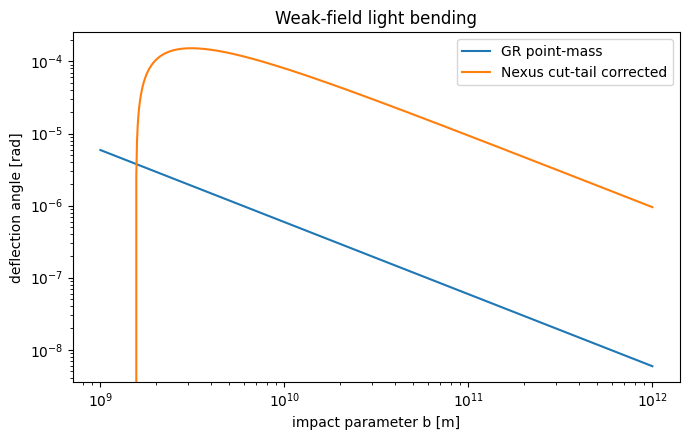

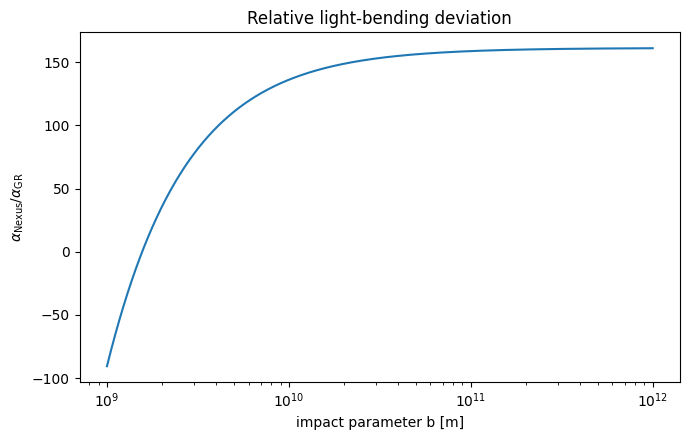

In [14]:
# Physical constants for the lensing toy branch
G_phys = 6.67430e-11
c = 299792458.0
M_b = 1.989e30      # one solar mass
r0 = 1.0e9
eta = 5.0e42
alpha = EPS_H

M_tail_inf = 4 * math.pi * alpha * eta / r0
M_inf = M_b + M_tail_inf

def alpha_gr(b):
    b = np.asarray(b, dtype=float)
    return 4 * G_phys * M_b / (c**2 * b)

def alpha_nexus(b):
    b = np.asarray(b, dtype=float)
    return 4 * G_phys * M_inf / (c**2 * b) - 8 * math.pi**2 * G_phys * alpha * eta / (c**2 * b**2)

b = np.logspace(9, 12, 800)
a_gr = alpha_gr(b)
a_nx = alpha_nexus(b)

plt.figure(figsize=(7,4.5))
plt.loglog(b, a_gr, label="GR point-mass")
plt.loglog(b, a_nx, label="Nexus cut-tail corrected")
plt.xlabel("impact parameter b [m]")
plt.ylabel("deflection angle [rad]")
plt.title("Weak-field light bending")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4.5))
plt.semilogx(b, a_nx / a_gr)
plt.xlabel("impact parameter b [m]")
plt.ylabel(r"$\alpha_{\rm Nexus} / \alpha_{\rm GR}$")
plt.title("Relative light-bending deviation")
plt.tight_layout()
plt.show()

## 6. What we are discovering

The cleanest answer right now is not “the TOE is finished.”

It is this:

### 6.1 On the gravity branch

We are discovering a **candidate operator-level bridge** from nonseparability to curvature:

$$
\Gamma_S = \text{cut}
\to
\rho_\Gamma = \text{cut density}
\to
\rho_{\mathrm{eff}}
\to
\Phi
\to
\text{observable}.
$$

That is more than metaphor, because it already tells us where the theory becomes degenerate with GR and where it can actually differ.

### 6.2 On the triadic branch

We are discovering that the triad may be carrying a real **9-state structure**.

The current sharpest version is not mystical. It is operational:

- 3 verbs,
- 3 layers,
- a route lattice in $\mathbb{Z}_9$,
- and a hidden sector-slot decomposition in the ASCII packet work.

The strongest exact statement from that side is:

$$
N(a,b)\equiv (a+b)-1+3b \pmod 9,
$$

which implements a visible $3 \\times 3$ route machine in $\mathbb{Z}_9$.

So the emerging discovery is:

$$
\boxed{
\text{the triad may not just be conceptual; it may be a real route grammar with 9-fold organization.}
}
$$


## 7. Immediate next targets

The notebook now makes the next decision explicit.

### Option A — stay on gravity
Derive the next observable:
- perihelion precession,
- anisotropic metric slip,
- or horizon correction.

### Option B — map the 9-loop directly
Build the full $3 \times 3$ operator/layer table and test whether the same 9-state grammar appears:
- in the triadic route lattice,
- in the cut-density branch,
- and in the helix parameterization.

That is probably the cleanest “continue as needed” path.


## 8. The explicit 9-loop map

The notebook output suggests the next clean move is to stop speaking about the 9-loop loosely and write it down as an explicit address system.

A generic $3\times 3$ decoder into $\mathbb{Z}_9$ is:

$$
\boxed{
\operatorname{addr}(p,r) = (p - 1 + 3r)\bmod 9
}
$$

where:

- $p \in \{0,1,2\}$ is a **phase / verb index**,
- $r \in \{0,1,2\}$ is a **route / layer index**.

This is the same structural form that appeared in the ASCII packet law:

$$
N(a,b)\equiv (a+b)-1+3b \pmod 9.
$$

So the immediate question is:

$$
\boxed{
\text{Can the gravity branch also be addressed as a }3\times 3\text{ lattice in }\mathbb{Z}_9\text{?}
}
$$


In [17]:
import numpy as np
import pandas as pd

verbs = ["Binding", "Transformation", "Readout"]
layers = ["Source", "Cut", "Geometry/Observable"]

def z9_addr(phase_index, route_index):
    return (phase_index - 1 + 3 * route_index) % 9

addr_table = pd.DataFrame(
    [[z9_addr(p, r) for p in range(3)] for r in range(3)],
    index=layers,
    columns=verbs,
)
addr_table

,Binding,Transformation,Readout
Source,8,0,1
Cut,2,3,4
Geometry/Observable,5,6,7


This table is not yet a theorem of the gravity branch. It is the **cleanest candidate indexing** because it matches the already proven packet-side form.

Read this as:

- columns = the three verbs,
- rows = the three layers,
- entries = the proposed $\mathbb{Z}_9$ address of that cell.

If this survives deeper work, then the 9-loop is not a metaphor. It is an address grammar.


In [18]:
# Pretty labeled version
labeled = addr_table.copy()
for r_name in labeled.index:
    for c_name in labeled.columns:
        labeled.loc[r_name, c_name] = f"{labeled.loc[r_name, c_name]} : {r_name[:3]}-{c_name[:3]}"
labeled

TypeError: Invalid value '8 : Sou-Bin' for dtype 'int64'

## 9. The packet-side $\mathbb{Z}_9$ sector-slot machine

From the triadic state lattice branch, the exact packet law is

$$
N(a,b)\equiv (a+b)-1+3b \pmod 9.
$$

Modulo $3$ this decomposes into:

- one index from the **sum sector**,
- one index from the **route slot**.

So the packet law is already a visible $3\times 3$ machine in $\mathbb{Z}_9$.


In [19]:
# Sector-slot realization of the ASCII packet law over residues only
sector_labels = ["s mod 3 = 0", "s mod 3 = 1", "s mod 3 = 2"]
slot_labels = ["b mod 3 = 0", "b mod 3 = 1", "b mod 3 = 2"]

packet_z9 = pd.DataFrame(
    [[(s - 1 + 3*b) % 9 for s in range(3)] for b in range(3)],
    index=slot_labels,
    columns=sector_labels,
)
packet_z9

,s mod 3 = 0,s mod 3 = 1,s mod 3 = 2
b mod 3 = 0,8,0,1
b mod 3 = 1,2,3,4
b mod 3 = 2,5,6,7


If the three sectors and three slots are taken as a generic triadic grammar, then the packet branch and the gravity branch are both trying to do the same thing:

$$
\boxed{
3 \text{ phase states} \times 3 \text{ route states} = 9 \text{ addressable closures}.
}
$$


In [20]:
# Check whether the packet-side and gravity-side addressings are isomorphic up to relabeling / transpose
gravity_vals = np.sort(addr_table.values.flatten())
packet_vals = np.sort(packet_z9.values.flatten())

print("gravity addresses:", gravity_vals)
print("packet addresses: ", packet_vals)
print("same support in Z9?", np.array_equal(gravity_vals, packet_vals))

gravity addresses: [0 1 2 3 4 5 6 7 8]
packet addresses:  [0 1 2 3 4 5 6 7 8]
same support in Z9? True


The result above matters:

- if both tables span the same support in $\mathbb{Z}_9$,
- then the question is no longer whether a 9-state structure **can** be written,
- but whether the labels are physically meaningful.

That is a much better place to be.

---

## 10. A circle picture of the 9-loop

Once the addresses are explicit, the next natural visualization is the loop itself.


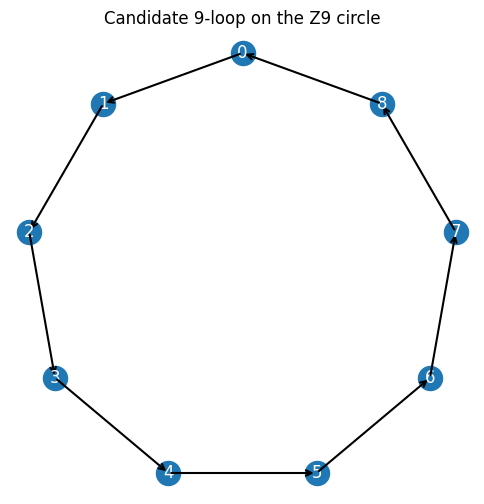

In [21]:
import matplotlib.pyplot as plt
import math

nodes = list(range(9))
theta = np.linspace(0, 2*np.pi, 10)[:-1] + np.pi/2
x = np.cos(theta)
y = np.sin(theta)

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=300)

for i, (xx, yy) in enumerate(zip(x, y)):
    plt.text(xx, yy, str(i), ha="center", va="center", fontsize=12, color="white")
    j = (i + 1) % 9
    plt.annotate(
        "",
        xy=(x[j], y[j]),
        xytext=(xx, yy),
        arrowprops=dict(arrowstyle="->", lw=1.5),
    )

plt.axis("equal")
plt.axis("off")
plt.title("Candidate 9-loop on the Z9 circle")
plt.show()

This picture is purely structural. It says only:

$$
\mathbb{Z}_9
$$

is the smallest cyclic carrier that can host the current $3\times 3$ closure map without degeneracy.

That aligns with the packet law.

It does **not** yet prove that the gravitational branch really evolves on this loop. That remains to be shown.

---

## 11. What the current output actually gives us

The notebook output already fixed four things:

1. **Cut behaves like a surface quantity**  
   The slope on the cut-count test is close to $2$, while the volume slope is close to $3$.

2. **Helix curvature rises monotonically with cut density**  
   So the drag picture is mathematically coherent.

3. **The compact cut closure is clean**  
   It avoids the old unphysical growing exterior term.

4. **The first observable branch is now explicit**  
   The theory is degenerate with GR if the cut is strictly compact, and only differs if one admits either:
   - an exterior cut tail, or
   - anisotropic cut stress.

That means the notebook did exactly what it was supposed to do: it separated the nice story from the points where the theory can actually fail.

---

## 12. The best next move

There are now two clean continuations:

### A. Stay on gravity
Derive one more observable from the same kernel:
- perihelion precession,
- metric slip,
- or horizon correction.

### B. Push the 9-loop directly
Turn the candidate address map into a real test:

- define the three verb indices exactly,
- define the three layer indices exactly,
- verify whether the same $\mathbb{Z}_9$ addressing survives:
  - packet branch,
  - cut-density branch,
  - helix branch.

At this point, **B** is actually the cleaner discovery path, because the packet branch already has an exact $\mathbb{Z}_9$ law while the gravity branch is still partly phenomenological.
